# GLORIA RRS data
https://doi.pangaea.de/10.1594/PANGAEA.948492

A global dataset of remote sensing reflectance and water quality from inland and coastal waters (GLORIA) includes many useful datasets for chlorophyll algorithm development.

First, read in the rrs data and the metadata and append relevant metadata variables

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [2]:
gloria_22 = pd.read_csv(r'C:\Users\gianna.milton\Documents\Python\one off cruises\GLORIA-2022\GLORIA_2022\GLORIA_meta_and_lab.csv') #metadata
excel_file = pd.read_csv(r'C:\Users\gianna.milton\Documents\Python\one off cruises\GLORIA-2022\GLORIA_2022\GLORIA_Rrs.csv') #rrs data
excel_file = excel_file.drop('GLORIA_ID', axis=1) #remove duplicate id column to ensure consistannt columns

since gloria_22 and excel_file are the exact same size and have the exact same ID values in the same order, we can drop the ID column in excel_file and just concat the two dataframes 

In [3]:
#since gloria_22 has the metadata for excel_file, and they match row wise, just concat
gloria_22 = pd.concat([gloria_22, excel_file],axis=1)
gloria_22 = gloria_22.dropna(axis=1, how='all')

columns_no=['GLORIA_ID', 'LIMNADES_ID', 'Data_collection_purpose','Sample_ID', 'Special_event_flag', 'Site_name', 'Country', 
             'Country_code', 'Platform','Water_body_type', 'Water_type', 'Elevation_asl', 'Wave_height', 'Wind_speed', 'Cloud_fraction', 'Distance_from_platform',
             'Platform_length', 'Platform_height', 'Distance_to_shore', 'Landcover', 'Topography','Distance_to_river_discharge', 
             'Optical_stability_of_water', 'Instrument_manufacturer', 'Instrument_model', 'Last_calibration', 'Measurement_method', 'Lt_nadir', 
             'Lt_relative_azimuth', 'Lsky_zenith','Lsky_relative_azimuth', 'Spectral_resolution', 'Number_of_radiometers','Field_of_view_Lt_radiometer',
             'Field_of_view_Lu_radiometer', 'Skyglint_removal', 'Bias_removal_in_NIR', 'Self_shading_correction','Viewing_angle_correction',
             'Availability_of_IOPs', 'Sample_depth', 'Water_collection_equipment', 'Chl_method', 'Phaeophytin_correction', 'TSS_method', 
             'aCDOM_method', 'Chla', 'Chla_plus_phaeo', 'TSS','aCDOM440', 'Turbidity', 'Secchi_depth', 'Comments']
gloria_22 = gloria_22.drop(columns_no, axis=1)

#rename columns 
gloria_22 = gloria_22.rename(columns={'Organization_ID':'affiliations','Dataset_ID':'experiment','Latitude':'lat','Longitude':'lon','Date_Time_UTC':'datetime',
                                  'Depth':'depth','SeaBASS_ID':'DOI_url'})


All of GLORIA's rrs columns are in the format rrs_wavelength (rrs_400, rrs_500, ect). So turn these into a single wavelength column and a single rrs column to best match the seabass one. 

In [4]:
#turn rrs into same format as seabass
rrs_cols = [col for col in gloria_22.columns if col.startswith('Rrs_')]

df_long = gloria_22.melt(id_vars=['affiliations', 'experiment', 'lat', 'lon', 'datetime', 'depth','DOI_url'], value_vars=rrs_cols,var_name='raw_wavelength',  value_name='rrs')
#remove the 'Rrs_' string from the column
df_long['raw_wavelength'] = df_long['raw_wavelength'].str.replace('Rrs_', '')
df_long['wavelength'] = pd.to_numeric(df_long['raw_wavelength'])
df_long = df_long.drop(columns=['raw_wavelength'])
df_long = df_long.dropna(subset=['rrs'])
df_long['source']='GLORIA'

In [5]:
#if DOI_url is empty, refer to the doi of paper 'https://doi.pangaea.de/10.1594/PANGAEA.948492
df_long['DOI_url'] = df_long['DOI_url'].fillna('https://doi.pangaea.de/10.1594/PANGAEA.948492')

In [6]:
#remove any inland data
shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(df_long, geometry=gpd.points_from_xy(df_long.lon, df_long.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
df_long = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
df_long = df_long.drop(columns=columns_to_drop)
df_long= df_long.reset_index(drop=True)

In [7]:
df_long = df_long[df_long['datetime'] >= '2000-01-01']

Done! 

# Plots

In [8]:
gloria = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\GLORIA_rrs_na.xlsx')


KeyboardInterrupt: 

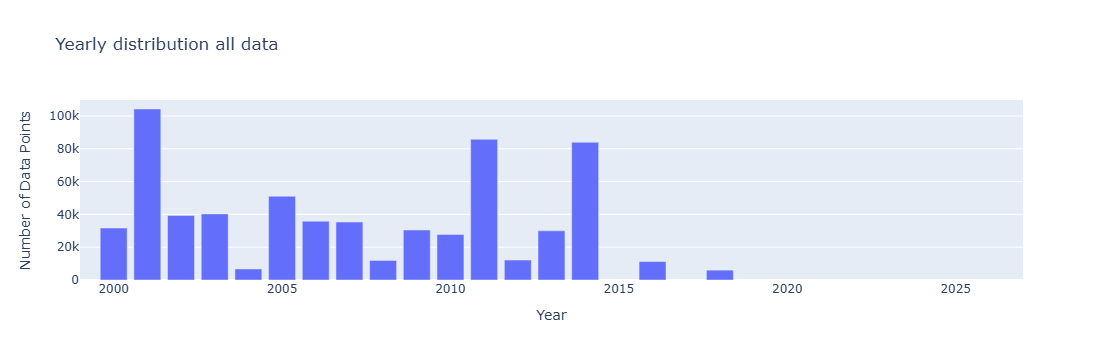

In [3]:
year_test=gloria.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

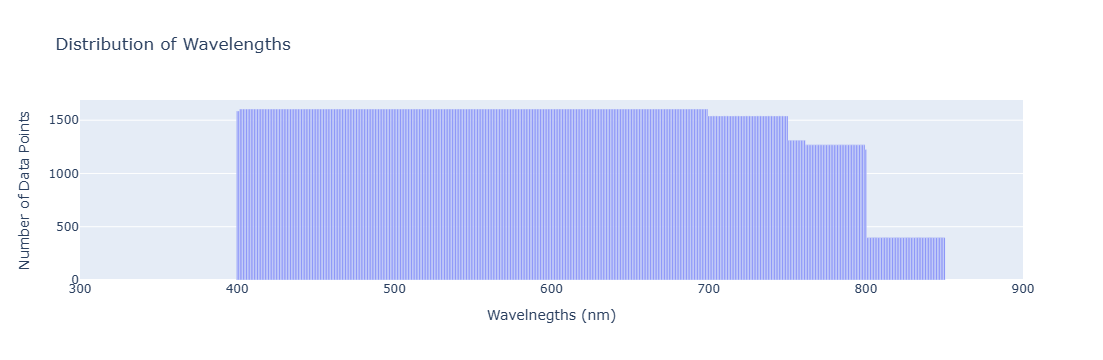

In [4]:
grouped = year_test.groupby(['wavelength']).size().reset_index(name='DataPoints')
# Create bar chart
fig = px.bar(grouped,x='wavelength', y='DataPoints', title='Distribution of Wavelengths',
             labels={'wavelength': 'Wavelnegths (nm)', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[300,900])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

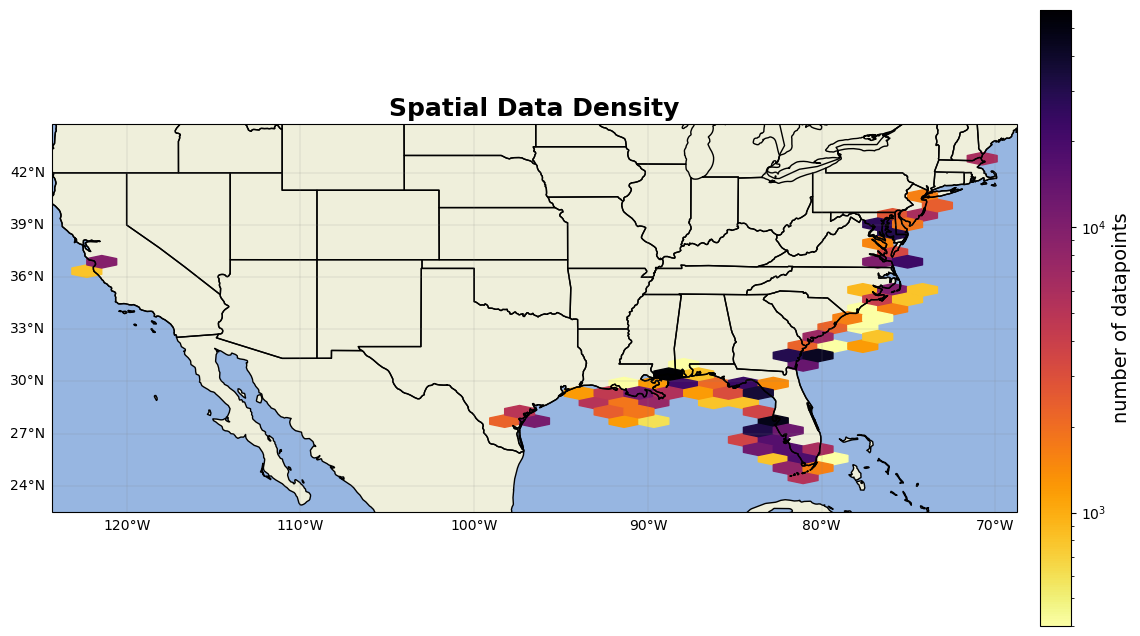

In [5]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=30, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)
ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()